##### HLE 2PL Item Analysis: Difficulty and Discrimination

This notebook estimates item difficulty and discrimination using a 2PL IRT model, matching the preprocessing/filtering used in `hle_cfa_analysis.ipynb`:

- Load `response_matrix.csv` with models as rows and items as columns.
- Drop models with response coverage `< 0.95`.
- Fill remaining missing values with `0.0`.
- Remove zero-variance items.
- Fit `torch_measure.models.TwoPL`.

Item categories come from local `hle_pilot.csv`.

## 0. Setup

In [43]:
# If running in a fresh environment, uncomment this cell.
# !pip install -q torch_measure matplotlib seaborn scipy scikit-learn pandas torch

In [44]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import torch
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import matplotlib.gridspec as gridspec
from matplotlib.patches import FancyBboxPatch
from matplotlib.lines import Line2D
import seaborn as sns
from scipy import stats
from torch_measure.models import TwoPL

warnings.filterwarnings("ignore")

# Publication style constants copied from hle_cfa_analysis.ipynb.
plt.rcParams.update({
    "figure.facecolor":    "white",
    "axes.facecolor":      "white",
    "axes.edgecolor":      "#2d2d2d",
    "axes.linewidth":      0.8,
    "axes.spines.top":     False,
    "axes.spines.right":   False,
    "axes.grid":           True,
    "axes.grid.axis":      "both",
    "grid.color":          "#e8e8e8",
    "grid.linewidth":      0.5,
    "axes.labelsize":      11,
    "axes.labelcolor":     "#2d2d2d",
    "axes.titlesize":      12,
    "axes.titleweight":    "semibold",
    "axes.titlecolor":     "#1a1a1a",
    "xtick.labelsize":     9,
    "ytick.labelsize":     9,
    "xtick.color":         "#4d4d4d",
    "ytick.color":         "#4d4d4d",
    "legend.fontsize":     9,
    "legend.framealpha":   0.92,
    "legend.edgecolor":    "#cccccc",
    "figure.dpi":          150,
    "savefig.dpi":         300,
    "savefig.bbox":        "tight",
    "font.family":         "serif",
    "font.serif":          ["Palatino Linotype", "Palatino", "Book Antiqua",
                             "Georgia", "DejaVu Serif"],
    "mathtext.fontset":    "dejavuserif",
})

DOMAIN_PALETTE = {
    "Biology/Medicine":          "#2166ac",
    "Math":                      "#d6604d",
    "Humanities/Social Science": "#4dac26",
    "Computer Science/AI":       "#8073ac",
    "Physics":                   "#f4a582",
    "Chemistry":                 "#1a9641",
    "Engineering":               "#fdae61",
    "Other":                     "#878787",
    "Unknown":                   "#cccccc",
}

NAVY   = "#1c3557"
ACCENT = "#c0392b"
TEAL   = "#16a085"
MID    = "#7f8c8d"

def domain_color(d):
    return DOMAIN_PALETTE.get(d, "#878787")

OUTPUT_DIR = Path("2pl_item_analysis_outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

print("Publication style loaded.")

Publication style loaded.


## 1. Load Data With Same Preprocessing as `hle_cfa_analysis.ipynb`

In [45]:
# This is intentionally the same filtering pipeline used in hle_cfa_analysis.ipynb.
df_raw = pd.read_csv("response_matrix.csv", index_col=0)

EXCLUDE_THRESHOLD = 0.95   # drop models with < 70% coverage
coverage = df_raw.notna().mean(axis=1)
excluded = coverage[coverage < EXCLUDE_THRESHOLD].index.tolist()
df_clean = df_raw.drop(index=excluded).fillna(0.0)

# Remove zero-variance items
zero_var = df_clean.columns[df_clean.var(axis=0) == 0]
df_clean = df_clean.drop(columns=zero_var)

X = torch.tensor(df_clean.values, dtype=torch.float32)
N, J = X.shape

print(f"Raw matrix: {df_raw.shape[0]} models × {df_raw.shape[1]} items")
print(f"Analytic matrix: N={N} models × J={J} items")
print(f"Excluded models ({len(excluded)}): {excluded}")
print(f"Zero-variance items removed: {len(zero_var)}")
print(f"Mean retained-model coverage before fill: {coverage.drop(index=excluded).mean():.3f}")

display(pd.DataFrame({
    "coverage": coverage,
    "retained": ~coverage.index.isin(excluded),
}).sort_values("coverage"))

Raw matrix: 36 models × 513 items
Analytic matrix: N=29 models × J=428 items
Excluded models (7): ['deepseek-r1', 'gpt-5-nano', 'gemini-2-5-pro', 'deepseek-v4-flash', 'deepseek-v4-pro', 'gemma9b-8k4k', 'phi4-16k8k']
Zero-variance items removed: 85
Mean retained-model coverage before fill: 0.992


,coverage,retained
deepseek-v4-flash,0.508772,False
deepseek-r1,0.516569,False
deepseek-v4-pro,0.538012,False
phi4-16k8k,0.565302,False
gemma9b-8k4k,0.635478,False
gemini-2-5-pro,0.676413,False
gpt-5-nano,0.840156,False
o3-mini,0.951267,True
o4-mini,0.951267,True
gpt-5-mini,0.957115,True


In [46]:
# Local HLE metadata: item category labels.
items = pd.read_csv("hle_pilot.csv")
items = items.set_index("item_id")

item_meta = items.reindex(df_clean.columns)
item_categories = item_meta["category"].fillna("Unknown")
item_subjects = item_meta["raw_subject"].fillna("Unknown")

category_order = item_categories.value_counts().index.tolist()
print("Category distribution after filtering:")
print(item_categories.value_counts().to_string())

display(pd.DataFrame({
    "category": item_categories,
    "raw_subject": item_subjects,
}).head())

Category distribution after filtering:
category
Biology/Medicine             122
Math                          78
Humanities/Social Science     71
Computer Science/AI           54
Other                         37
Physics                       26
Chemistry                     22
Engineering                   18


,category,raw_subject
668825f80a642802bdfeadfa,Humanities/Social Science,Philosophy
66e4cdec11c64a7e4051b2d9,Computer Science/AI,Artificial Intelligence
66e8784d70625d8c7700315a,Computer Science/AI,Artificial Intelligence
66e883265ab37f0a7da089be,Other,Chess
66e88728ba7d8bc0d5806f3a,Biology/Medicine,Bioinformatics


## 2. Fit 2PL Model

In [47]:
# Same 2PL fit settings as the CFA notebook.
irt = TwoPL(n_subjects=N, n_items=J)
irt.fit(X, method="mle", max_epochs=2000, lr=0.05, verbose=True)

A_CAP = 5.0

a_raw = irt.discrimination.detach().cpu()
a_hat = a_raw.clamp(max=A_CAP)
b_hat = irt.difficulty.detach().cpu()
theta_hat = irt.ability.detach().cpu()

item_params = pd.DataFrame({
    "item_id": df_clean.columns,
    "category": item_categories.values,
    "raw_subject": item_subjects.values,
    "discrimination_raw": a_raw.numpy(),
    "discrimination": a_hat.numpy(),
    "difficulty": b_hat.numpy(),
    "mean_accuracy": df_clean.mean(axis=0).values,
    "n_correct": df_clean.sum(axis=0).values,
    "n_models": N,
})
item_params["pct_correct"] = item_params["mean_accuracy"] * 100
item_params["difficulty_percentile"] = item_params["difficulty"].rank(pct=True) * 100
item_params["discrimination_percentile"] = item_params["discrimination"].rank(pct=True) * 100

item_params.to_csv(OUTPUT_DIR / "2pl_item_parameters.csv", index=False)
print(f"Saved item parameters to {OUTPUT_DIR / '2pl_item_parameters.csv'}")

display(item_params.describe(include="all"))

MLE fitting:  14%|█▍        | 284/2000 [00:00<00:01, 1129.42it/s, loss=0.319572]


Saved item parameters to 2pl_item_analysis_outputs/2pl_item_parameters.csv


,item_id,category,raw_subject,discrimination_raw,discrimination,difficulty,mean_accuracy,n_correct,n_models,pct_correct,difficulty_percentile,discrimination_percentile
count,428,428,428,428.000000,428.000000,428.000000,428.000000,428.000000,428.0,428.000000,428.000000,428.000000
unique,428,8,84,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,668825f80a642802bdfeadfa,Biology/Medicine,Mathematics,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,1,122,65,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,5.921850,2.156842,0.941122,0.166371,4.824766,29.0,16.637125,50.116822,50.116822
std,NaN,NaN,NaN,22.292368,1.728837,1.563809,0.112561,3.264262,0.0,11.256075,28.901218,28.810215
min,NaN,NaN,NaN,0.004928,0.004928,-2.058874,0.034483,1.000000,29.0,3.448276,0.233645,0.233645
25%,NaN,NaN,NaN,0.675622,0.675622,-0.284663,0.068966,2.000000,29.0,6.896552,25.175234,25.175234
50%,NaN,NaN,NaN,1.485053,1.485053,0.411866,0.137931,4.000000,29.0,13.793103,50.116822,50.116822
75%,NaN,NaN,NaN,3.632046,3.632046,2.080819,0.241379,7.000000,29.0,24.137931,75.058411,75.058411


## 3. Overall Difficulty and Discrimination Distributions

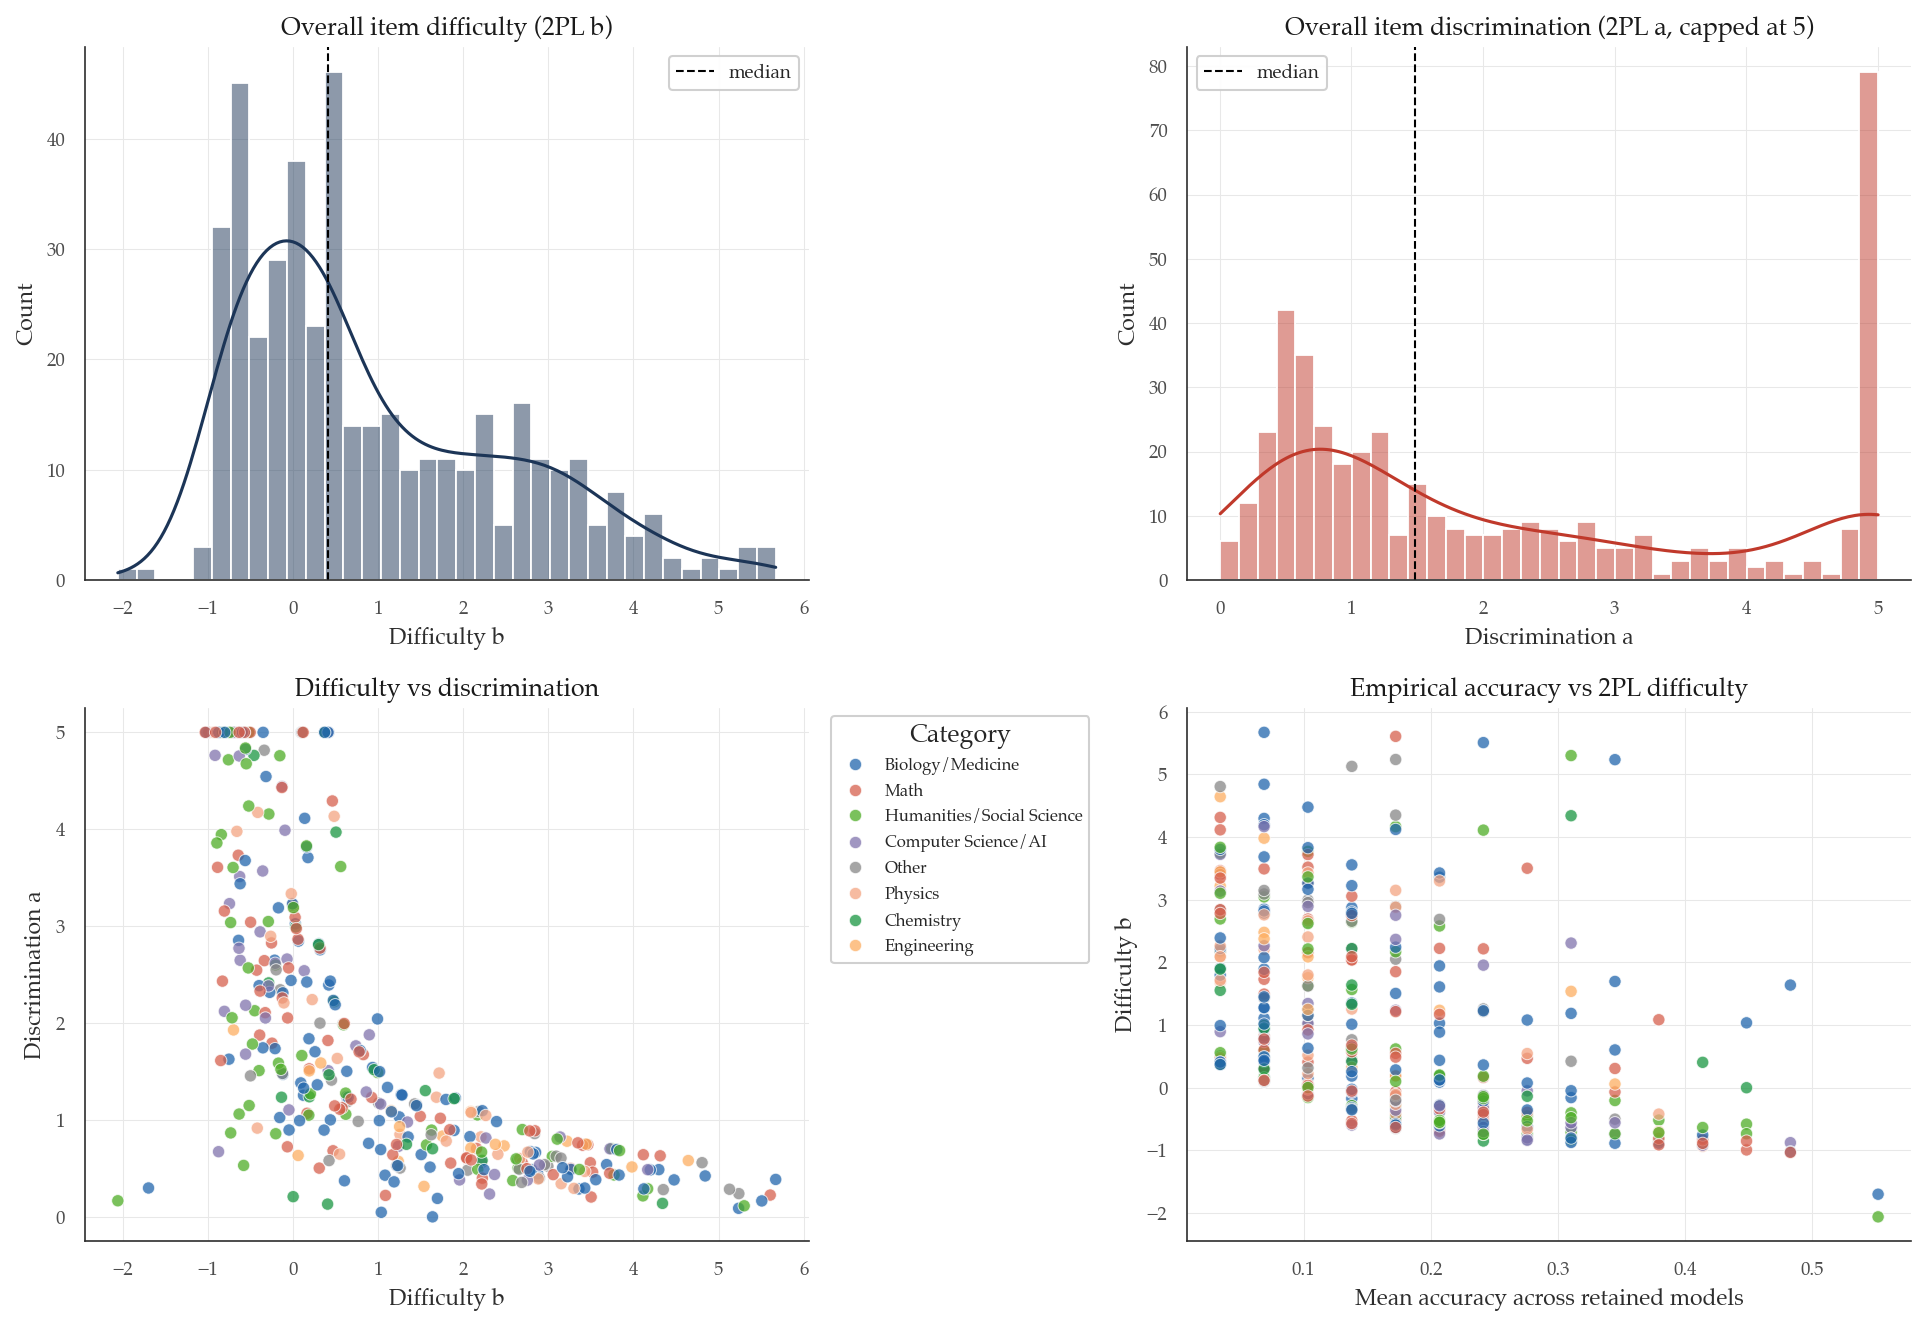

In [48]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

sns.histplot(item_params["difficulty"], kde=True, bins=35, ax=axes[0, 0], color=NAVY)
axes[0, 0].axvline(item_params["difficulty"].median(), color="black", ls="--", lw=1, label="median")
axes[0, 0].set_title("Overall item difficulty (2PL b)")
axes[0, 0].set_xlabel("Difficulty b")
axes[0, 0].legend()

sns.histplot(item_params["discrimination"], kde=True, bins=35, ax=axes[0, 1], color=ACCENT)
axes[0, 1].axvline(item_params["discrimination"].median(), color="black", ls="--", lw=1, label="median")
axes[0, 1].set_title(f"Overall item discrimination (2PL a, capped at {A_CAP:g})")
axes[0, 1].set_xlabel("Discrimination a")
axes[0, 1].legend()

sns.scatterplot(
    data=item_params,
    x="difficulty",
    y="discrimination",
    hue="category",
    hue_order=category_order,
    palette=DOMAIN_PALETTE,
    alpha=0.75,
    s=35,
    ax=axes[1, 0],
)
axes[1, 0].set_title("Difficulty vs discrimination")
axes[1, 0].set_xlabel("Difficulty b")
axes[1, 0].set_ylabel("Discrimination a")
axes[1, 0].legend(title="Category", bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)

sns.scatterplot(
    data=item_params,
    x="mean_accuracy",
    y="difficulty",
    hue="category",
    hue_order=category_order,
    palette=DOMAIN_PALETTE,
    alpha=0.75,
    s=35,
    ax=axes[1, 1],
    legend=False,
)
axes[1, 1].set_title("Empirical accuracy vs 2PL difficulty")
axes[1, 1].set_xlabel("Mean accuracy across retained models")
axes[1, 1].set_ylabel("Difficulty b")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "overall_2pl_distributions.png", bbox_inches="tight")
plt.show()

In [49]:
overall_summary = item_params[["difficulty", "discrimination", "mean_accuracy"]].agg(
    ["count", "mean", "std", "min", "median", "max"]
).T

overall_summary["p10"] = item_params[["difficulty", "discrimination", "mean_accuracy"]].quantile(0.10)
overall_summary["p25"] = item_params[["difficulty", "discrimination", "mean_accuracy"]].quantile(0.25)
overall_summary["p75"] = item_params[["difficulty", "discrimination", "mean_accuracy"]].quantile(0.75)
overall_summary["p90"] = item_params[["difficulty", "discrimination", "mean_accuracy"]].quantile(0.90)

overall_summary.to_csv(OUTPUT_DIR / "overall_2pl_summary.csv")
display(overall_summary.round(3))

,count,mean,std,min,median,max,p10,p25,p75,p90
difficulty,428.0,0.941,1.564,-2.059,0.412,5.672,-0.705,-0.285,2.081,3.315
discrimination,428.0,2.157,1.729,0.005,1.485,5.000,0.437,0.676,3.632,5.000
mean_accuracy,428.0,0.166,0.113,0.034,0.138,0.552,0.034,0.069,0.241,0.310


## 4. Category-Level Distributions

In [50]:
category_summary = (
    item_params
    .groupby("category")
    .agg(
        n_items=("item_id", "count"),
        mean_difficulty=("difficulty", "mean"),
        median_difficulty=("difficulty", "median"),
        sd_difficulty=("difficulty", "std"),
        mean_discrimination=("discrimination", "mean"),
        median_discrimination=("discrimination", "median"),
        sd_discrimination=("discrimination", "std"),
        mean_accuracy=("mean_accuracy", "mean"),
        median_accuracy=("mean_accuracy", "median"),
    )
    .sort_values("median_difficulty", ascending=False)
)
category_summary.to_csv(OUTPUT_DIR / "category_2pl_summary.csv")
display(category_summary.round(3))

,n_items,mean_difficulty,median_difficulty,sd_difficulty,mean_discrimination,median_discrimination,sd_discrimination,mean_accuracy,median_accuracy
category,,,,,,,,,
Engineering,18,1.748,1.648,1.452,1.008,0.769,0.603,0.132,0.103
Physics,26,1.226,1.471,1.420,1.806,1.065,1.534,0.146,0.103
Other,37,1.521,1.218,1.677,1.720,1.091,1.690,0.136,0.138
Biology/Medicine,122,1.031,0.438,1.594,2.095,1.353,1.747,0.163,0.138
Math,78,0.929,0.436,1.586,2.022,1.574,1.590,0.175,0.138
Chemistry,22,0.646,0.390,1.167,2.386,1.495,1.866,0.161,0.138
Computer Science/AI,54,0.494,0.100,1.356,2.818,2.635,1.804,0.172,0.155
Humanities/Social Science,71,0.621,0.096,1.613,2.486,1.985,1.815,0.192,0.172


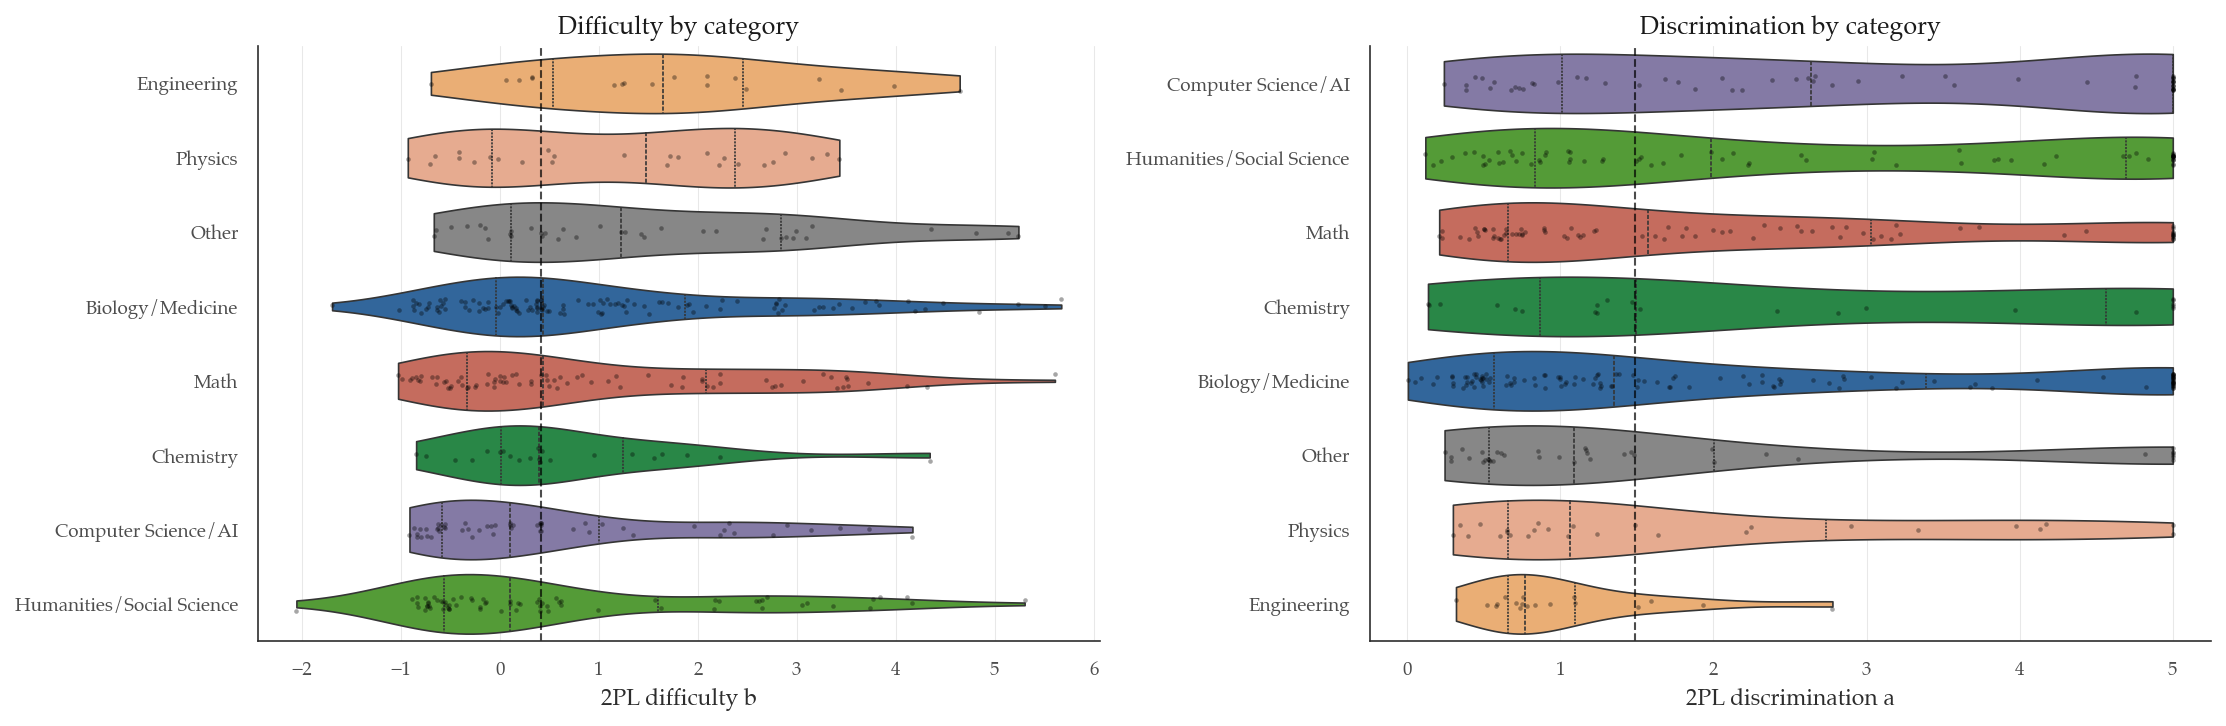

In [51]:
fig, axes = plt.subplots(1, 2, figsize=(15, max(5, 0.45 * len(category_order))))

diff_order = category_summary.index.tolist()
disc_order = category_summary.sort_values("median_discrimination", ascending=False).index.tolist()

sns.violinplot(
    data=item_params,
    y="category",
    x="difficulty",
    order=diff_order,
    inner="quartile",
    cut=0,
    linewidth=0.8,
    ax=axes[0],
    palette=[domain_color(d) for d in diff_order],
)
sns.stripplot(
    data=item_params,
    y="category",
    x="difficulty",
    order=diff_order,
    color="black",
    alpha=0.35,
    size=2.2,
    ax=axes[0],
)
axes[0].axvline(item_params["difficulty"].median(), color="black", ls="--", lw=1, alpha=0.7)
axes[0].set_title("Difficulty by category")
axes[0].set_xlabel("2PL difficulty b")
axes[0].set_ylabel("")

sns.violinplot(
    data=item_params,
    y="category",
    x="discrimination",
    order=disc_order,
    inner="quartile",
    cut=0,
    linewidth=0.8,
    ax=axes[1],
    palette=[domain_color(d) for d in disc_order],
)
sns.stripplot(
    data=item_params,
    y="category",
    x="discrimination",
    order=disc_order,
    color="black",
    alpha=0.35,
    size=2.2,
    ax=axes[1],
)
axes[1].axvline(item_params["discrimination"].median(), color="black", ls="--", lw=1, alpha=0.7)
axes[1].set_title("Discrimination by category")
axes[1].set_xlabel("2PL discrimination a")
axes[1].set_ylabel("")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "category_2pl_violins.png", bbox_inches="tight")
plt.show()

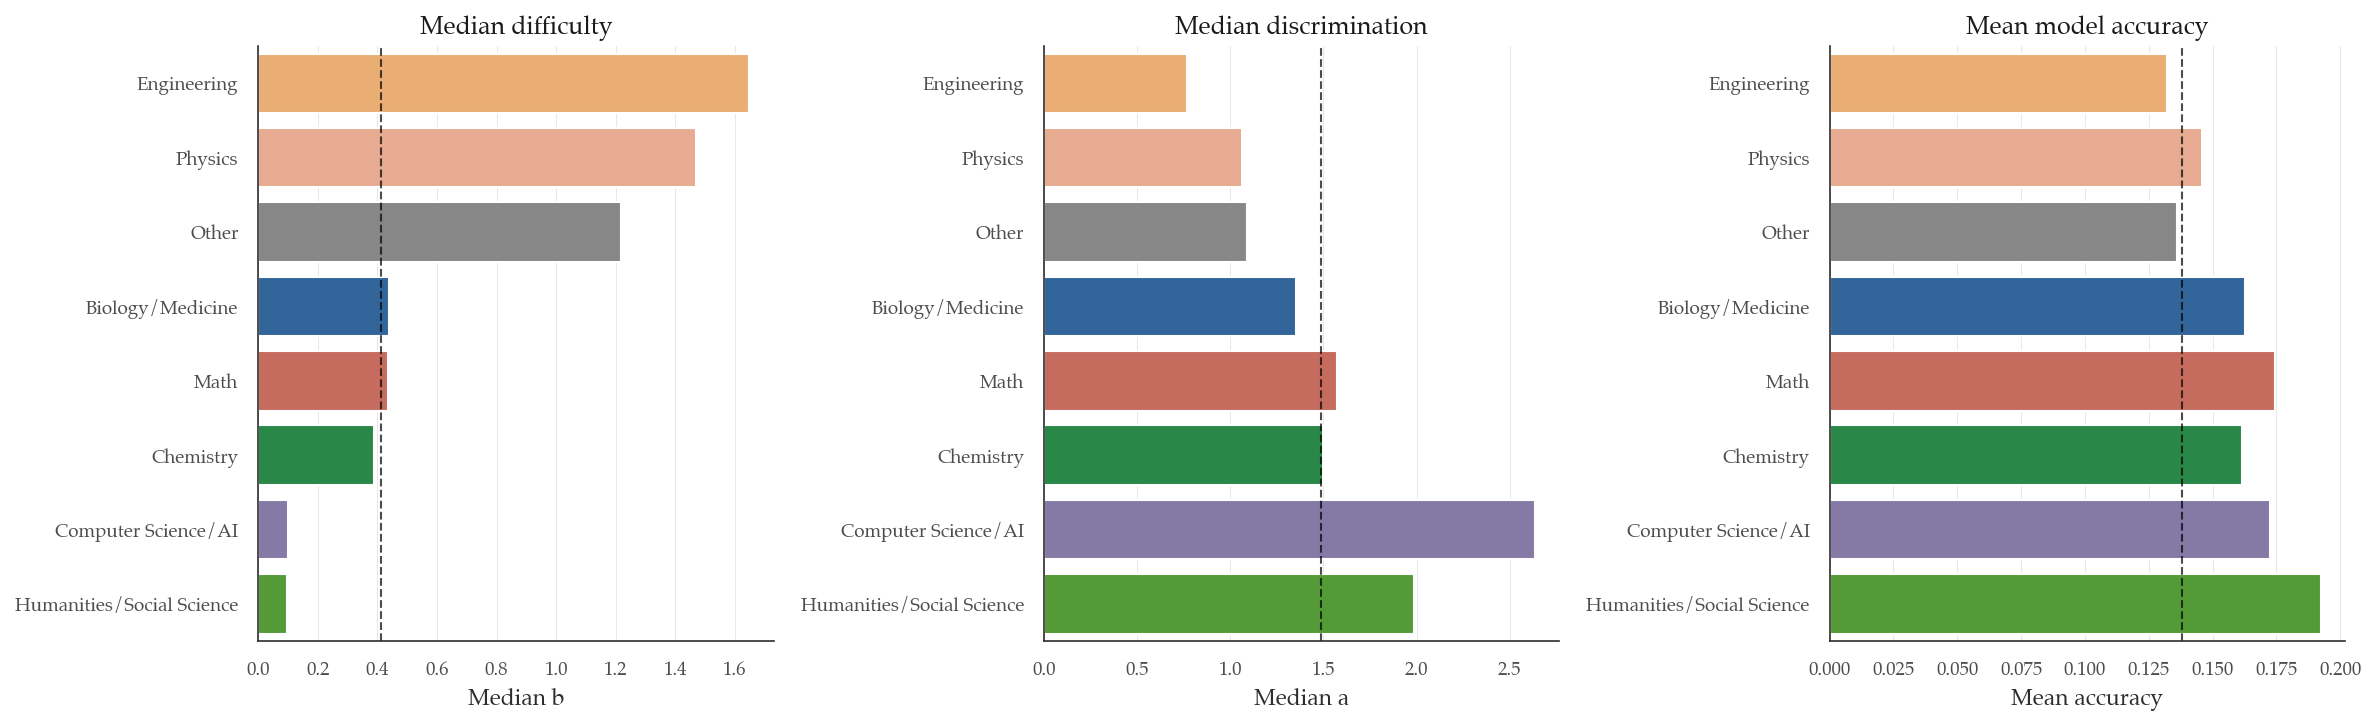

In [52]:
fig, axes = plt.subplots(1, 3, figsize=(16, max(5, 0.4 * len(category_order))))
plot_summary = category_summary.reset_index()

sns.barplot(data=plot_summary, y="category", x="median_difficulty", order=diff_order, ax=axes[0], palette=[domain_color(d) for d in diff_order])
axes[0].axvline(item_params["difficulty"].median(), color="black", ls="--", lw=1, alpha=0.7)
axes[0].set_title("Median difficulty")
axes[0].set_xlabel("Median b")
axes[0].set_ylabel("")

sns.barplot(data=plot_summary, y="category", x="median_discrimination", order=diff_order, ax=axes[1], palette=[domain_color(d) for d in diff_order])
axes[1].axvline(item_params["discrimination"].median(), color="black", ls="--", lw=1, alpha=0.7)
axes[1].set_title("Median discrimination")
axes[1].set_xlabel("Median a")
axes[1].set_ylabel("")

sns.barplot(data=plot_summary, y="category", x="mean_accuracy", order=diff_order, ax=axes[2], palette=[domain_color(d) for d in diff_order])
axes[2].axvline(item_params["mean_accuracy"].median(), color="black", ls="--", lw=1, alpha=0.7)
axes[2].set_title("Mean model accuracy")
axes[2].set_xlabel("Mean accuracy")
axes[2].set_ylabel("")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "category_2pl_summary_bars.png", bbox_inches="tight")
plt.show()

## 5. Category Facets

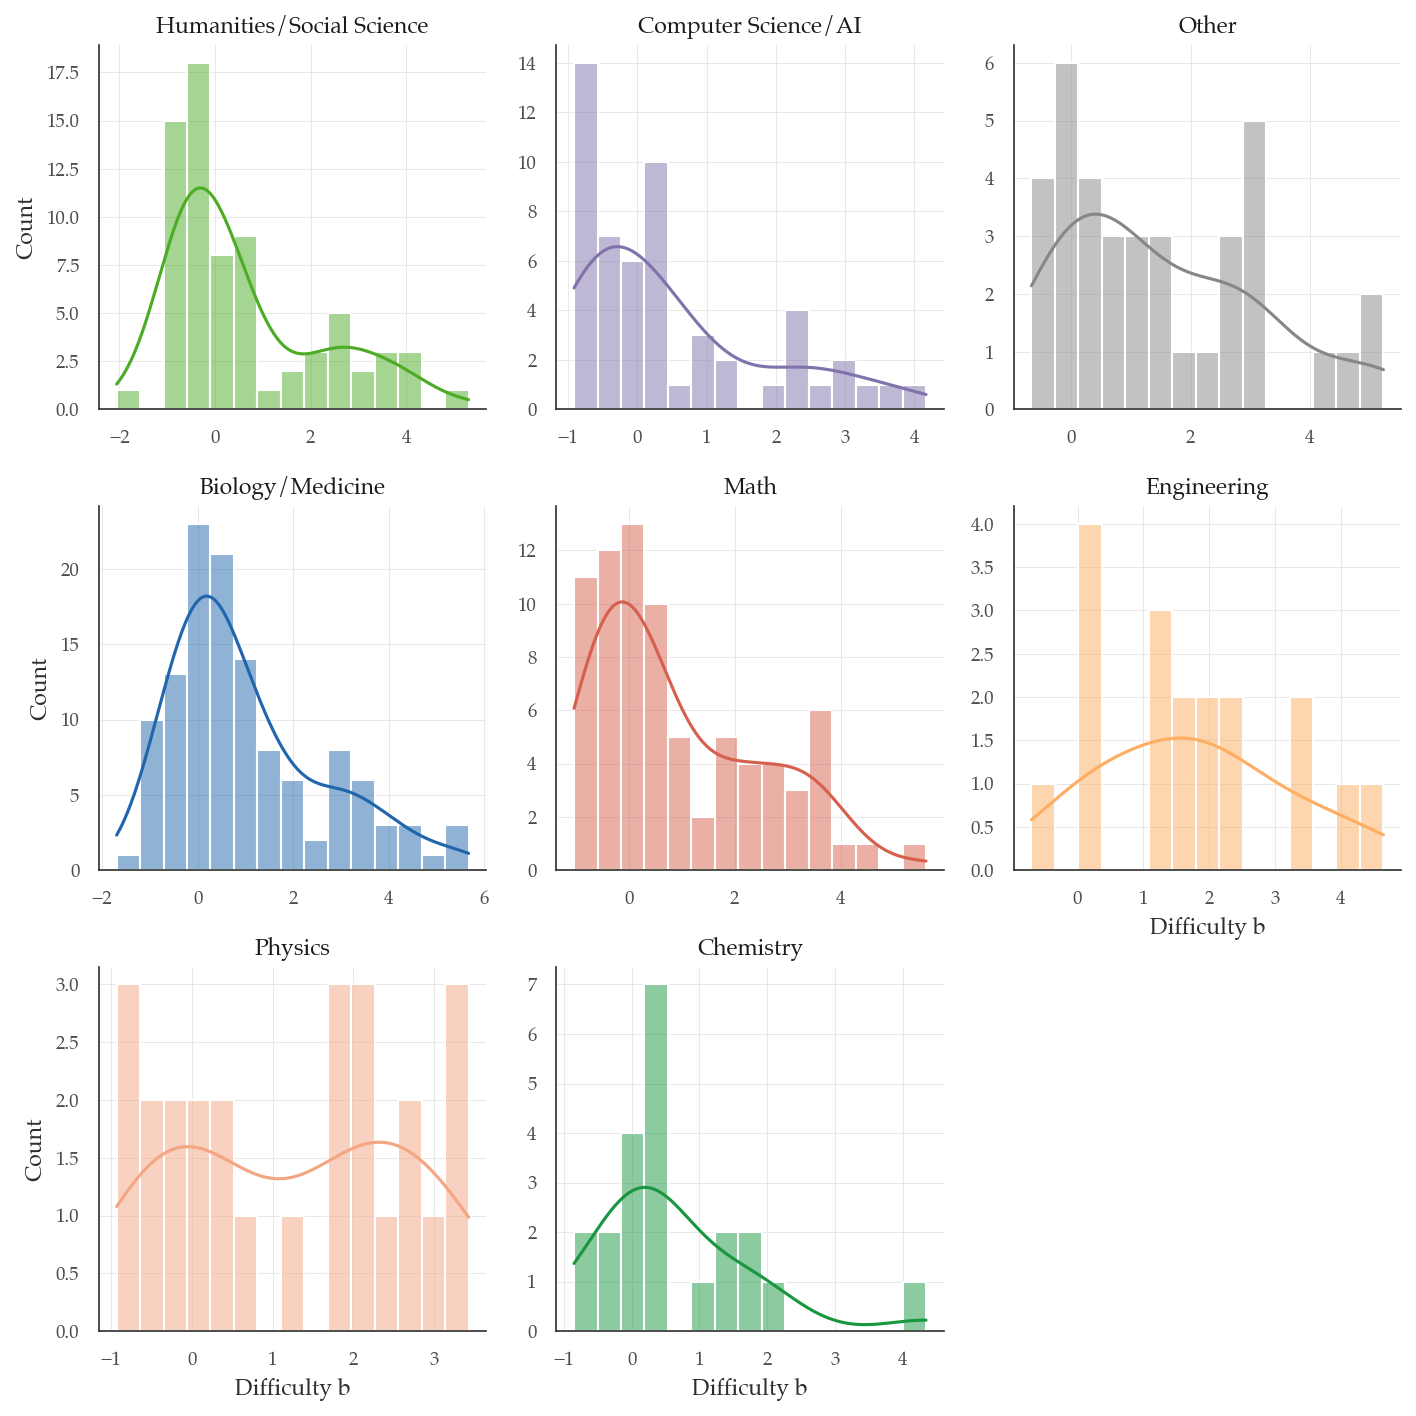

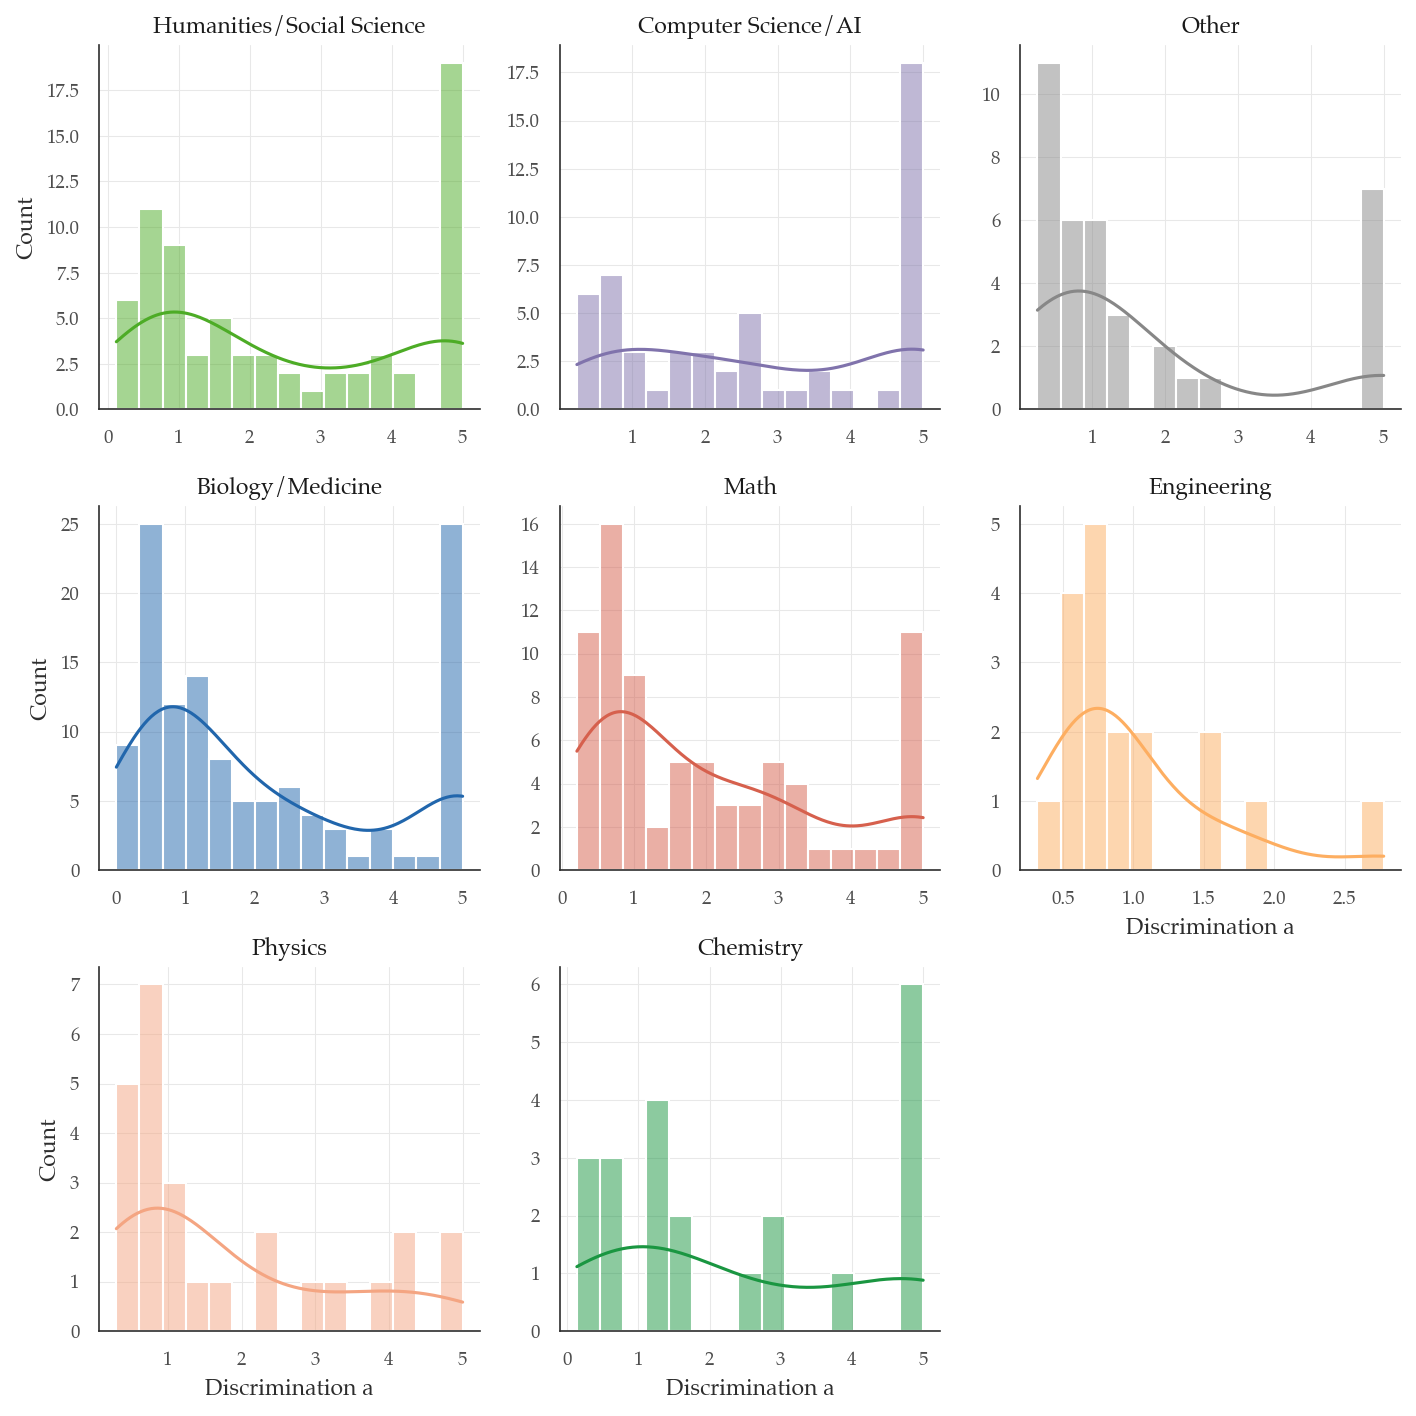

In [53]:
def category_hist(data, x, **kwargs):
    category = data["category"].iloc[0]
    kwargs.pop("color", None)
    sns.histplot(
        data=data,
        x=x,
        bins=15,
        kde=True,
        color=domain_color(category),
        **kwargs,
    )

g = sns.FacetGrid(
    item_params,
    col="category",
    col_wrap=3,
    sharex=False,
    sharey=False,
    height=3.2,
)
g.map_dataframe(category_hist, x="difficulty")
g.set_axis_labels("Difficulty b", "Count")
g.set_titles("{col_name}")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "category_difficulty_facets.png", bbox_inches="tight")
plt.show()

g = sns.FacetGrid(
    item_params,
    col="category",
    col_wrap=3,
    sharex=False,
    sharey=False,
    height=3.2,
)
g.map_dataframe(category_hist, x="discrimination")
g.set_axis_labels("Discrimination a", "Count")
g.set_titles("{col_name}")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "category_discrimination_facets.png", bbox_inches="tight")
plt.show()

## 6. Most Difficult / Easiest / Most Discriminating Items

In [54]:
def show_items(df, title, columns=None, n=15):
    if columns is None:
        columns = ["item_id", "category", "raw_subject", "difficulty", "discrimination", "mean_accuracy", "n_correct"]
    print(title)
    display(df[columns].head(n).round({"difficulty": 3, "discrimination": 3, "mean_accuracy": 3}))

show_items(item_params.sort_values("difficulty", ascending=False), "Most difficult items")
show_items(item_params.sort_values("difficulty", ascending=True), "Easiest items")
show_items(item_params.sort_values("discrimination", ascending=False), "Most discriminating items")
show_items(item_params.sort_values("discrimination", ascending=True), "Least discriminating items")

Most difficult items


,item_id,category,raw_subject,difficulty,discrimination,mean_accuracy,n_correct
304,67255df04c0e045943574e41,Biology/Medicine,Genetics,5.672,0.391,0.069,2.0
160,67178b22b7f6dd9be2a4dd68,Math,Mathematics,5.608,0.229,0.172,5.0
273,67241750cf2f76f66b81fe10,Biology/Medicine,Genetics,5.508,0.169,0.241,7.0
328,6726941826b7fc6a39fbe581,Humanities/Social Science,Linguistics,5.301,0.119,0.310,9.0
225,67204844452d0bd5546e11ef,Other,Earth Science,5.239,0.244,0.172,5.0
293,672500151d07f0962c8993d7,Biology/Medicine,Genetics,5.236,0.093,0.345,10.0
240,67219b2486e95ac1054387bc,Other,Logic,5.129,0.289,0.138,4.0
269,6724102248afc025aa35bce8,Biology/Medicine,Genetics,4.843,0.427,0.069,2.0
321,6725ed2e26992c47ce3a7eb1,Other,Ballroom Dancing,4.807,0.563,0.034,1.0
278,672423111ebc6d08d02c7f2d,Engineering,Biomedical Engineering,4.645,0.585,0.034,1.0


Easiest items


,item_id,category,raw_subject,difficulty,discrimination,mean_accuracy,n_correct
17,66e9a39f2dad0e536fb92efa,Humanities/Social Science,Philosophy,-2.059,0.171,0.552,16.0
381,67372744600c9c0daa5d8f3f,Biology/Medicine,Medicine,-1.698,0.302,0.552,16.0
195,671dc2145167d65f41c86c58,Math,Mathematics,-1.031,5.000,0.483,14.0
85,66fc89ce455038a48ed359e4,Biology/Medicine,Theoretical Biology,-1.021,5.000,0.483,14.0
26,66eadaf22b7de7dec0a046bd,Math,Mathematics,-0.991,5.000,0.448,13.0
60,66f378a504165ae3e4f46de9,Physics,Physics,-0.933,5.000,0.414,12.0
164,67180e9b814516d5f513eb3c,Computer Science/AI,Artificial Intelligence,-0.916,4.763,0.414,12.0
404,673c138655928a6b1b360ada,Math,Mathematics,-0.910,5.000,0.379,11.0
138,670f39dc1dcaeb830ff6231f,Humanities/Social Science,Linguistics,-0.895,3.859,0.414,12.0
409,674365a2b5d4e34a242899c5,Math,Mathematics,-0.887,3.608,0.414,12.0


Most discriminating items


,item_id,category,raw_subject,difficulty,discrimination,mean_accuracy,n_correct
0,668825f80a642802bdfeadfa,Humanities/Social Science,Philosophy,-0.759,5.0,0.241,7.0
64,66f4979d41a8777b61cf391a,Humanities/Social Science,Philosophy,0.394,5.0,0.034,1.0
230,6720cd0acf47ec0733864dd8,Chemistry,Chemistry,-0.745,5.0,0.241,7.0
221,671ff58624e49a0a566a7894,Other,Film Studies,0.096,5.0,0.069,2.0
213,671f40348b7ca154256661c6,Biology/Medicine,Ecology,-0.885,5.0,0.345,10.0
212,671f39dcd579cf064f22d3c1,Biology/Medicine,Ecology,-0.822,5.0,0.276,8.0
205,671f0c2578ab3005e439aeba,Biology/Medicine,Biology,-0.635,5.0,0.172,5.0
195,671dc2145167d65f41c86c58,Math,Mathematics,-1.031,5.0,0.483,14.0
415,67607764fd6487bd2bb7e271,Humanities/Social Science,Poetry,0.376,5.0,0.034,1.0
187,671c0d6f66154e5cf55994de,Chemistry,Chemistry,-0.849,5.0,0.241,7.0


Least discriminating items


,item_id,category,raw_subject,difficulty,discrimination,mean_accuracy,n_correct
84,66fc5e611f5f3f3b48ae9566,Biology/Medicine,Neuroscience,1.639,0.005,0.483,14.0
374,67366bc5b5eda7e01fa935c6,Biology/Medicine,Medicine,1.037,0.052,0.448,13.0
293,672500151d07f0962c8993d7,Biology/Medicine,Genetics,5.236,0.093,0.345,10.0
328,6726941826b7fc6a39fbe581,Humanities/Social Science,Linguistics,5.301,0.119,0.310,9.0
397,673ad4214ff8ec86c1487ed3,Chemistry,Chemistry,0.406,0.136,0.414,12.0
192,671d91bcad7fb0793a0e93bd,Chemistry,Chemistry,4.342,0.144,0.310,9.0
273,67241750cf2f76f66b81fe10,Biology/Medicine,Genetics,5.508,0.169,0.241,7.0
17,66e9a39f2dad0e536fb92efa,Humanities/Social Science,Philosophy,-2.059,0.171,0.552,16.0
232,6720fcd2198910fd26b01218,Biology/Medicine,Computational Biology,1.697,0.195,0.345,10.0
183,671aee77ed3d54e87368bc9a,Math,Mathematics,3.503,0.209,0.276,8.0


## 7. Optional: Item Information Curves by Category

For a 2PL item, information is `I_j(theta) = a_j^2 P_j(theta)(1-P_j(theta))`, where `P_j(theta) = sigmoid(a_j(theta-b_j))`.

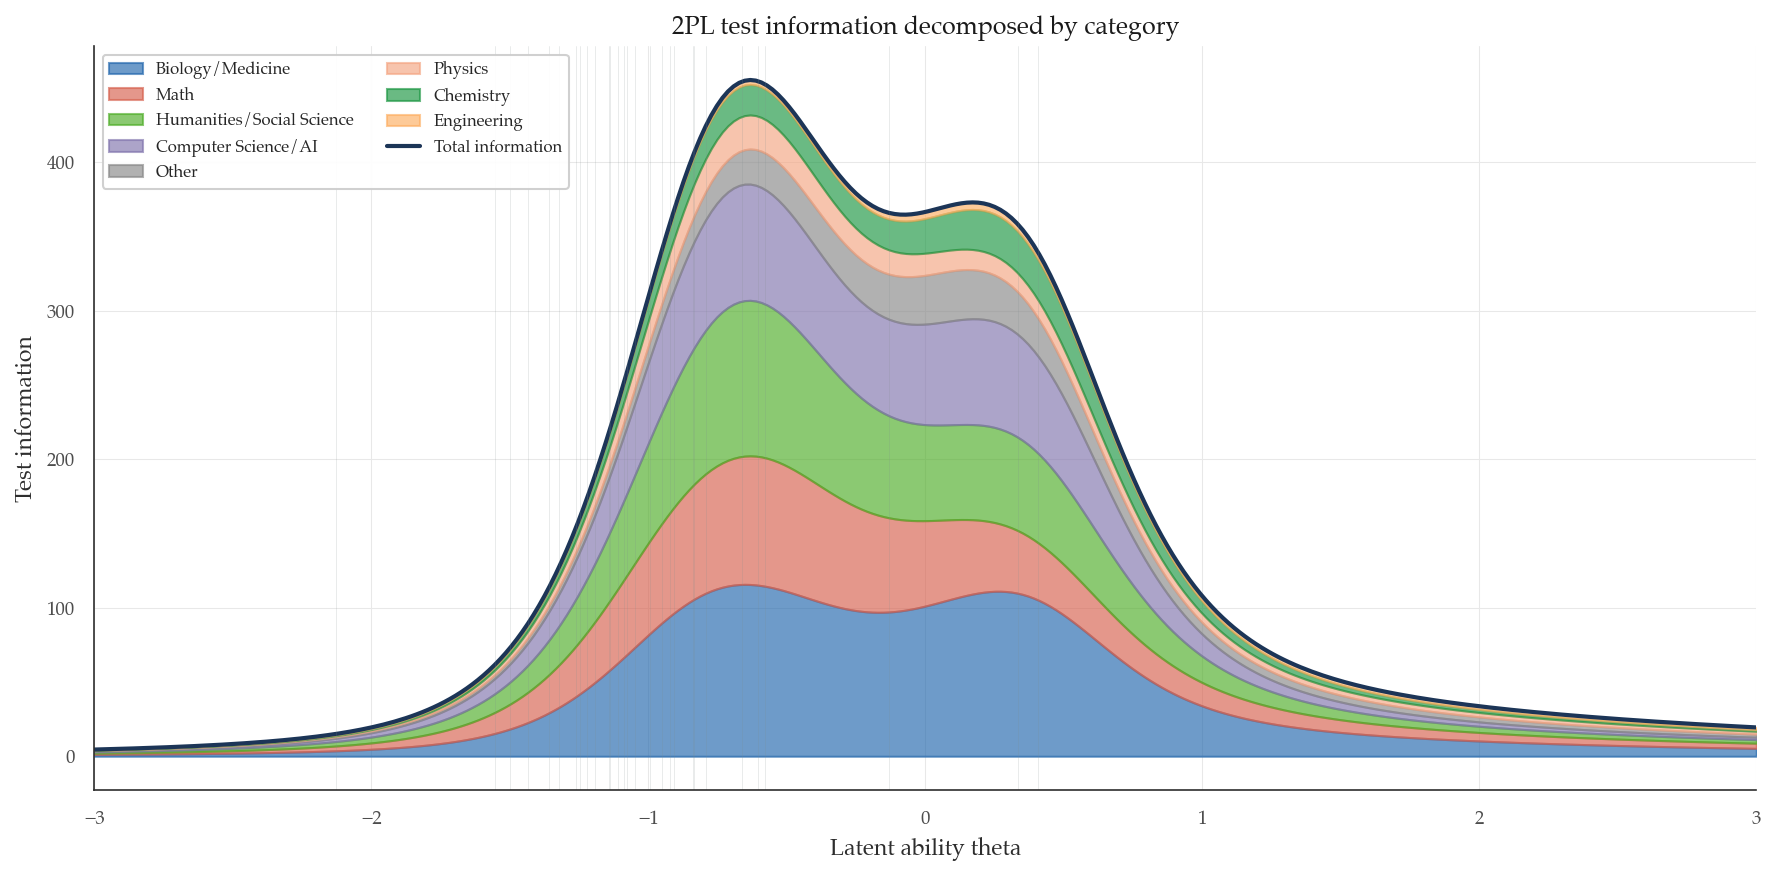

In [55]:
theta_grid = torch.linspace(-3, 3, 300)
P_grid = torch.sigmoid(
    a_hat.unsqueeze(0) * (theta_grid.unsqueeze(1) - b_hat.unsqueeze(0))
)
I_grid = a_hat.unsqueeze(0) ** 2 * P_grid * (1 - P_grid)
I_test = I_grid.sum(dim=1).numpy()

domain_info = {}
for category in category_order:
    mask = torch.tensor((item_categories == category).values)
    domain_info[category] = I_grid[:, mask].sum(dim=1).numpy()

fig, ax = plt.subplots(figsize=(12, 6))
bottom = np.zeros(len(theta_grid))
for category in category_order:
    y = domain_info[category]
    ax.fill_between(theta_grid.numpy(), bottom, bottom + y, color=domain_color(category), alpha=0.65, label=category)
    bottom += y
ax.plot(theta_grid.numpy(), I_test, color=NAVY, lw=2, label="Total information")
for th in theta_hat.numpy():
    ax.axvline(th, color=MID, lw=0.4, alpha=0.2)
ax.set_xlim(-3, 3)
ax.set_xlabel("Latent ability theta")
ax.set_ylabel("Test information")
ax.set_title("2PL test information decomposed by category")
ax.legend(fontsize=8, ncol=2, loc="upper left")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "category_item_information.png", bbox_inches="tight")
plt.show()

## 8. Exported Outputs

In [ ]:
print("Wrote outputs to:", OUTPUT_DIR.resolve())
for path in sorted(OUTPUT_DIR.glob("*")):
    print(path.name)